# Using EEG to Differentiate Alzheimer's, Frontotemporal Dementia, and Healthy Cognitive Aging

Author: Navami Shenoy   
Date: April 23, 2026      


## Background 
Alzheimer's Disease (AD) and Frontotemporal Dementia (FTD) are two common forms of dementia. Differentiating between AD and FTD early and accurately during diagnosis is notoriously difficult because their clinical symptoms often overlap in early stages, but their treatment paths are very different. A non-invasive, low-cost diagnostic tool based on EEG could reduce the reliance on invasive spinal taps and expensive and high-radiation scans like CT and PET. Therefore, the primary stakeholders who would be interested in such diagnostic tools would be neurologists and clinical researchers, as the ability to distinguish between AD and FTD in a timely and cost-effective manner would improve patient prognosis and management. 

Though development of diagnostic tools is a long multi-stage process, we can start with a simpler question that we can address in this project: **can we develop a multiclass classifier that accurately distinguishes between AD, FTD, and healthy cognitive aging using EEG features and demographic/clinical variables?**

## Dataset 
This dataset was collected by researchers at the AHEPA General University Hospital in Greece and was published in Data and OpenNeuro in 2023. It contains scalp EEG recordings from 88 participants divided into three roughly balanced classes: 36 AD patients, 23 FTD patients, and 29 healthy controls, and represents real-world clinical data. It includes 19-channel EEG signals recorded during a resting state (eyes closed), along with demographic data (age, sex) and cognitive test scores (Mini-Mental State Examination or MMSE).   

Data journal article: https://www.mdpi.com/2306-5729/8/6/95      
Download link: https://openneuro.org/datasets/ds004504/versions/1.0.8  

This dataset is well-suited for modeling intended for developing a low-cost, non-invasive diagnostic tool as it offers a clear separation of EEG and clinical data into three balanced classes, allowing us to train a model that can distinguish AD from FTD using EEG signals. 

This question is best approached as a **3-class classification problem (AD vs FTD vs Control)** as the dataset provides clearly separated and balanced classes that would help us better differentiate AD from FTD.

In [1]:
#!pip install matplotlib mne pandas numpy scipy scikit-learn seaborn 

In [2]:
import os
import glob
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt 
import seaborn as sns 
import mne
import scipy
from sklearn.decomposition import PCA 
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.model_selection import StratifiedKFold, GridSearchCV, cross_val_predict, cross_validate, cross_val_score
from sklearn.linear_model import LogisticRegression 
from sklearn.svm import SVC 
from sklearn.ensemble import RandomForestClassifier 
from sklearn.tree import DecisionTreeClassifier, plot_tree 
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, f1_score, make_scorer, precision_score
%run helper_functions.py 

## Data Exploration and Preprocessing
Preprocessing EEG signals involves removal of noise and artifacts (muscle activity, blinking, swallowing) and requires domain-specific knowledge. Luckily for me, this dataset provides preprocessed data I can work with, but still requires a few additional steps of processing. Primarily, the preprocessed data consists of time-series EEG signals from each of the 19 channels, which can be decomposed into 5 standard frequency bands: alpha, beta, delta, theta, and gamma. After extracting each frequency band from each channel, I would have 19*5 = 95 EEG channel features per participant. To stabilize variance and normalize the values, a log10 transformation will be applied to the frequency features. After merging with clinical variables (age, sex, and MMSE), I’d have a total of 98 features to start with, which is a perfect opportunity to apply feature selection using PCA or Lasso Regularization to avoid overfitting. 

The following diagram from this [source](https://link.springer.com/rwe/10.1007/978-3-319-56782-2_24-3) shows how the 19 channels are mapped all over the scalp to record electrical activity of different brain regions (some use more than 19 channels):  
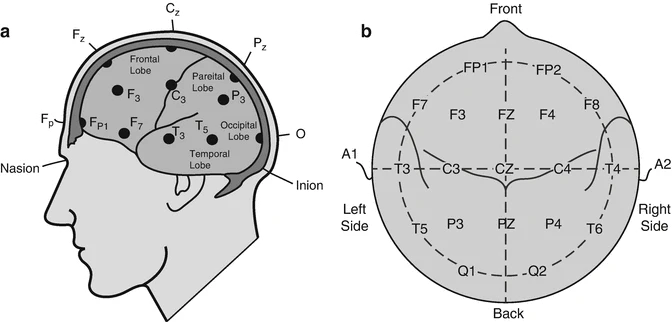

### Preprocessing
The following code performs the preprocessing steps outlined above:
1. The code first goes through each subject's EEG (.set) files that contained the processed, raw signal. It reads the signal data using mne library's standard functions. The custom function load_any_eeg() implements this.
2. For each participant's EEG signal, it calculates the average power for each of the 5 frequency bands across all 19 channels using calculate_band_power(). This results in 95 band features per participant, which is stored in a dataframe.
3. Finally, these features are merged with the tabular data in participants.tsv that contains the demographic and clinical variables. This merged result is saved as 'ds004504_tabular_features.csv' which will be the dataframe used for downstream analysis.

The dependency **helper_functions.py** contains load_any_eeg() and calculate_band_power() and explains in detail what these functions do, which includes applying the **log transformation**. 

In [3]:
# 1. Define Paths 
bids_root = './ds004504'
derivatives_dir = os.path.join(bids_root, 'derivatives')
participants_file = os.path.join(bids_root, 'participants.tsv')

# 2. Define the standard EEG frequency bands
freq_bands = {
    'Delta': (1.0, 4.0),
    'Theta': (4.0, 8.0),
    'Alpha': (8.0, 12.0),
    'Beta': (12.0, 30.0),
    'Gamma': (30.0, 45.0)
}


def main():
    print("Starting EEG Feature Extraction...")
    
    # List to hold the extracted features for all subjects
    all_subject_features = []
    
    # Find all preprocessed EEG files in the derivatives folder
    # BIDS derivatives often use .set (EEGLAB) or .edf format. 
    # Change '*.set' to '*.edf' if the dataset uses EDF files for derivatives.
    eeg_files = glob.glob(os.path.join(derivatives_dir, '**', '*_eeg.set'), recursive=True)
    
    if not eeg_files:
        # Fallback check in case they are .edf files
        eeg_files = glob.glob(os.path.join(derivatives_dir, '**', '*.edf'), recursive=True)
        
    print(f"Found {len(eeg_files)} preprocessed EEG files.")

    for filepath in eeg_files:
        try:
            # Extract subject ID from filename (e.g., 'sub-001')
            filename = os.path.basename(filepath)
            sub_id = filename.split('_')[0]
            print(f"Processing {sub_id}...")

            # Load the preprocessed EEG data
            raw = load_any_eeg(filepath)

            # Extract features
            features = calculate_band_power(raw)
            features['participant_id'] = sub_id # Add ID to merge later
            
            all_subject_features.append(features)
            
        except Exception as e:
            print(f"Error processing {filepath}: {e}")

    # Convert the list of dictionaries to a Pandas DataFrame
    eeg_df = pd.DataFrame(all_subject_features)
    
    # Load the participants.tsv file (contains Diagnosis/Group)
    participants_df = pd.read_csv(participants_file, sep='\t')
    
    # Merge the EEG features with the clinical labels based on participant_id
    final_dataset = pd.merge(participants_df, eeg_df, on='participant_id', how='inner')
    
    # Save the final tabular dataset to a CSV
    output_filename = 'ds004504_tabular_features.csv'
    final_dataset.to_csv(output_filename, index=False)
    
    print(f"\nSuccess! Tabular dataset created: {output_filename}")
    print(f"Dataset shape: {final_dataset.shape}")
    print(final_dataset.head())

if __name__ == '__main__':
    main()

The following processed dataframe ('ds004504_tabular_features.csv' outputed from the previous step) contains participant IDs, Gender (M/F), Age, MMSE (cognitive scores), and 95 columns corresponding to the 5 frequency bands from each of the 19 scalp electrode channels. In these EEG column names, the prefix represents the channel name, following by the frequency band name. Each row corresponds to clinical and EEG data from one participants, with a total of 88 rows. 
The target variable is the "Group" column, which represents whether the participant was healthy (C), or was diagnosed with AD (A) or FTD (F).

In [4]:
# Load the processsed, tabulated data 
df = pd.read_csv('ds004504_tabular_features.csv') 
print("Number of rows: ", len(df))
df.head()

Number of rows:  88


,participant_id,Gender,Age,Group,MMSE,Fp1_Delta,Fp1_Theta,Fp1_Alpha,Fp1_Beta,Fp1_Gamma,...,Cz_Delta,Cz_Theta,Cz_Alpha,Cz_Beta,Cz_Gamma,Pz_Delta,Pz_Theta,Pz_Alpha,Pz_Beta,Pz_Gamma
0,sub-001,F,57,A,16,-9.721912,-9.951221,-9.987582,-9.996062,-9.997241,...,-9.737827,-9.964086,-9.990351,-9.997623,-9.999301,-9.733281,-9.958947,-9.989709,-9.997680,-9.999396
1,sub-002,F,78,A,22,-9.761139,-9.962636,-9.974566,-9.996108,-9.998115,...,-9.757235,-9.966191,-9.984577,-9.997184,-9.999361,-9.756024,-9.961164,-9.968346,-9.996880,-9.999330
2,sub-003,M,70,A,14,-9.752766,-9.943198,-9.959626,-9.997210,-9.999266,...,-9.767389,-9.958151,-9.982256,-9.997530,-9.999406,-9.770145,-9.952362,-9.965114,-9.997330,-9.999452
3,sub-004,F,67,A,20,-9.733198,-9.963179,-9.989716,-9.995827,-9.996471,...,-9.733348,-9.963183,-9.990078,-9.997402,-9.999128,-9.734815,-9.961920,-9.990102,-9.997530,-9.999017
4,sub-005,M,70,A,22,-9.723526,-9.959292,-9.987449,-9.995448,-9.996469,...,-9.733181,-9.964129,-9.989959,-9.997544,-9.999354,-9.733282,-9.963661,-9.988457,-9.997244,-9.999237


The classes appear to be sufficiently balanced, and there are no missing values. The distributions of MMSE, Age, and Gender by the target group show that MMSE offers the most discriminating power, as the cognitive scores of AD, FTD, and controls fall in separate ranges. Gender may help in flagging AD cases better as well, since they were predominantly female, while controls and FTD subjects had similar male:female ratios. Age distribution appears similar across groups, which is ideal as we are interested in neurodegeneration and aging and the sample must be controlled for age. Consequently, age will likely not make it to the list of predictors as it offers little discriminating power.

Class Balance: 
Group
A    36
C    29
F    23
Name: count, dtype: int64

Missing Values: 
0


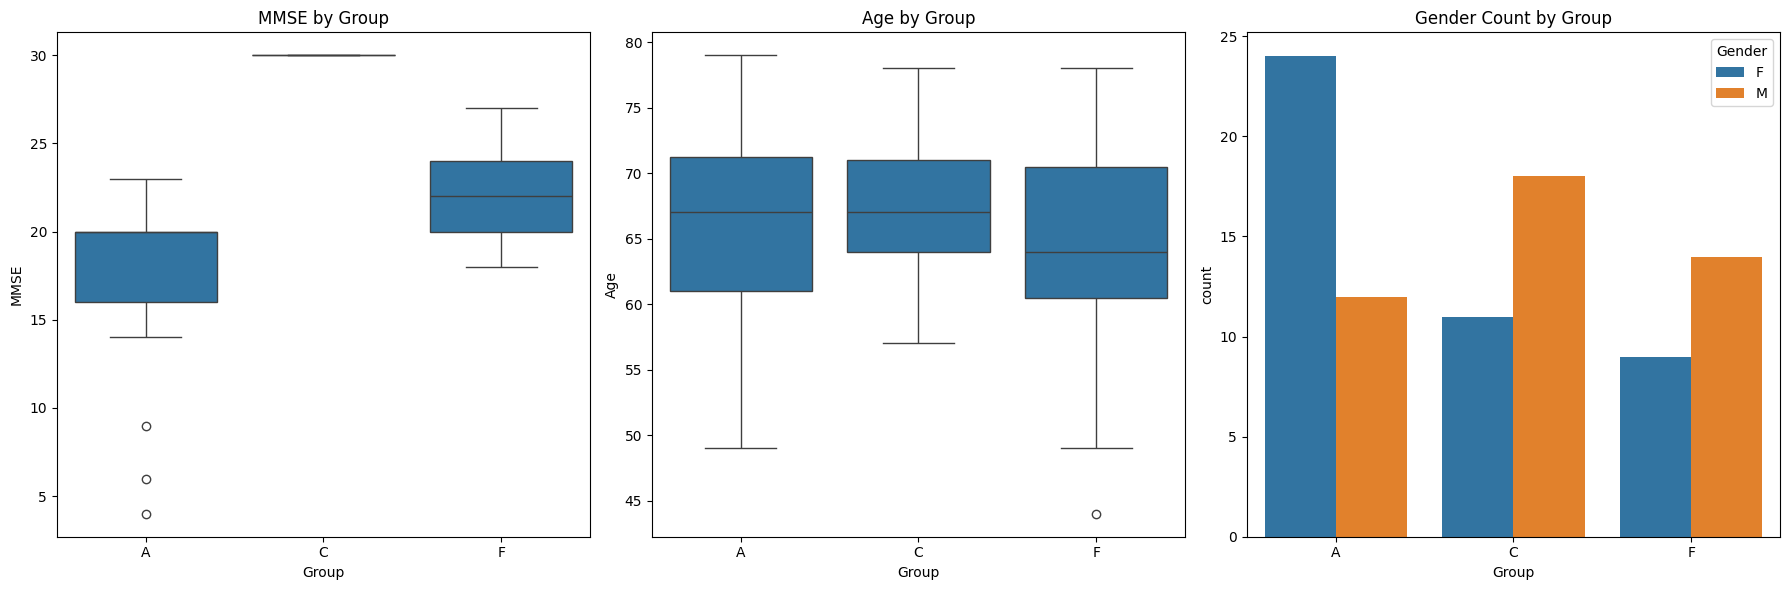

In [5]:
# Check class balance
print("Class Balance: ")
print(df['Group'].value_counts())

# Check for missing values
print("\nMissing Values: ")
print(df.isnull().sum().sum())

fig, axes = plt.subplots(1, 3, figsize=(18, 6))
# Distribution of MMSE by Diagnosis Group 
sns.boxplot(x='Group', y='MMSE', data=df, ax=axes[0])
axes[0].set_title('MMSE by Group')

# Distribution of Age by Diagnosis Group 
sns.boxplot(x='Group', y='Age', data=df, ax=axes[1])
axes[1].set_title('Age by Group')

# Distribution of Gender by Diagnosis Group
sns.countplot(x='Group', hue='Gender', data=df, ax=axes[2])
axes[2].set_title('Gender Count by Group')

plt.tight_layout()
plt.show()

### Examining correlations between same-frequency EEG features 
Now, we can focus solely on the 95 EEG features. 
The heatmaps show that there is high correlation among features within the same frequency band, indicating that a lot of features from the same band provide similar information and only a few from each band would be relevant for modeling. 

### Examining correlations between EEG Features and Diagnosis Group
Lastly, the individual correlations between the EEG features and the target variable is quite weak. The highest correlation between any single feature and the diagnosis is only about 0.35, which suggests that no single feature can provide a linear answer and diagnosis is hidden in the complex coordination of signals from the whole brain.   
Also, an important observation to make would be that features most correlated with the diagnosis class seem to be coming from the theta band, which can be relevant for making interpretations later on.

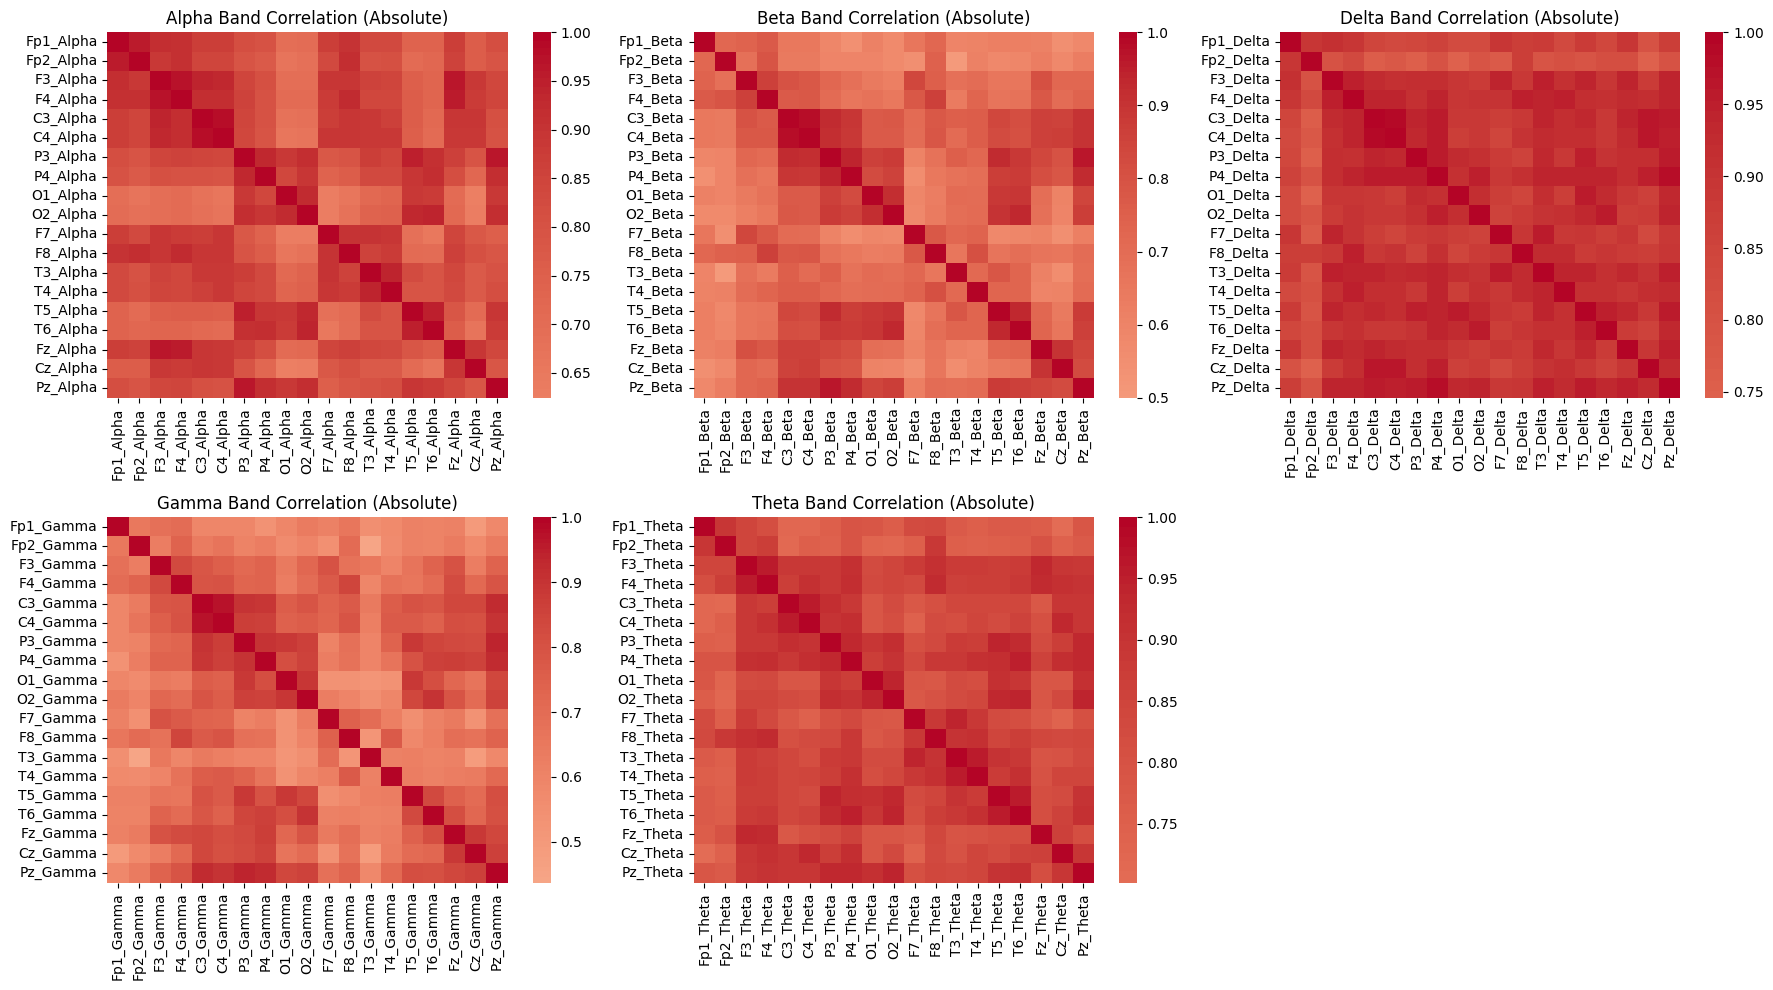

Top 10 features correlated with Diagnosis (Absolute Spearman Correlation):
F4_Theta: 0.3492
Fz_Theta: 0.3408
F7_Theta: 0.3391
T3_Theta: 0.3196
F3_Theta: 0.3160
P3_Theta: 0.2776
F8_Theta: 0.2763
P4_Theta: 0.2669
T4_Theta: 0.2625
F7_Delta: 0.2603


In [6]:
# --------------- EEG Feature Correlations --------------- #
# 1. HEATMAPS: Check correlations between frequency bands
fig, axes = plt.subplots(2, 3, figsize=(18, 10)) 
axes = axes.flatten()

# Generate heatmaps for features belonging to the same 
# frequency band across all channels
for i, band in enumerate(sorted(freq_bands.keys())):
    band_features = [col for col in df.columns if band in col]
    if band_features:  # safety check
        sns.heatmap(
            df[band_features].corr(method="spearman"), # using spearman to not assume linearity and normality
            cmap='coolwarm',
            center=0,
            ax=axes[i]
        )
        axes[i].set_title(f'{band} Band Correlation (Absolute)')

# Remove the unused 6th subplot
fig.delaxes(axes[-1])
plt.tight_layout()
plt.show()

# 2. Check correlation between EEG features and the target variable Group
# Drop all non-EEG features
X = df.drop(columns=['participant_id', 'Group', 'Gender', 'Age', 'MMSE']) 
y = df['Group'] 

le = LabelEncoder() 
y_numeric = le.fit_transform(y) 
correlations = [] 

for col in X.columns:
    corr, _ = scipy.stats.spearmanr(X[col], y_numeric)
    correlations.append((col, abs(corr)))
correlations.sort(key=lambda x: x[1], reverse=True)
print("Top 10 features correlated with Diagnosis (Absolute Spearman Correlation):")
for item in correlations[:10]:
    print(f"{item[0]}: {item[1]:.4f}")

### PCA Analysis
The PCA analysis of EEG features shows that the three Diagnosis groups are heavily entangled in the first two principal components (plot on the left), and there is no straight line or hyperplane that can separate them. This indicates the relationship might be predominantly non-linear. This lack of differentiation persists after removing within-band features that were highly correlated with each other (corr>0.8) (plot on the right). 

This lack of linear separation in low dimensions necessitates non-linear models like Support Vector Machines (SVM) and Random Forest.

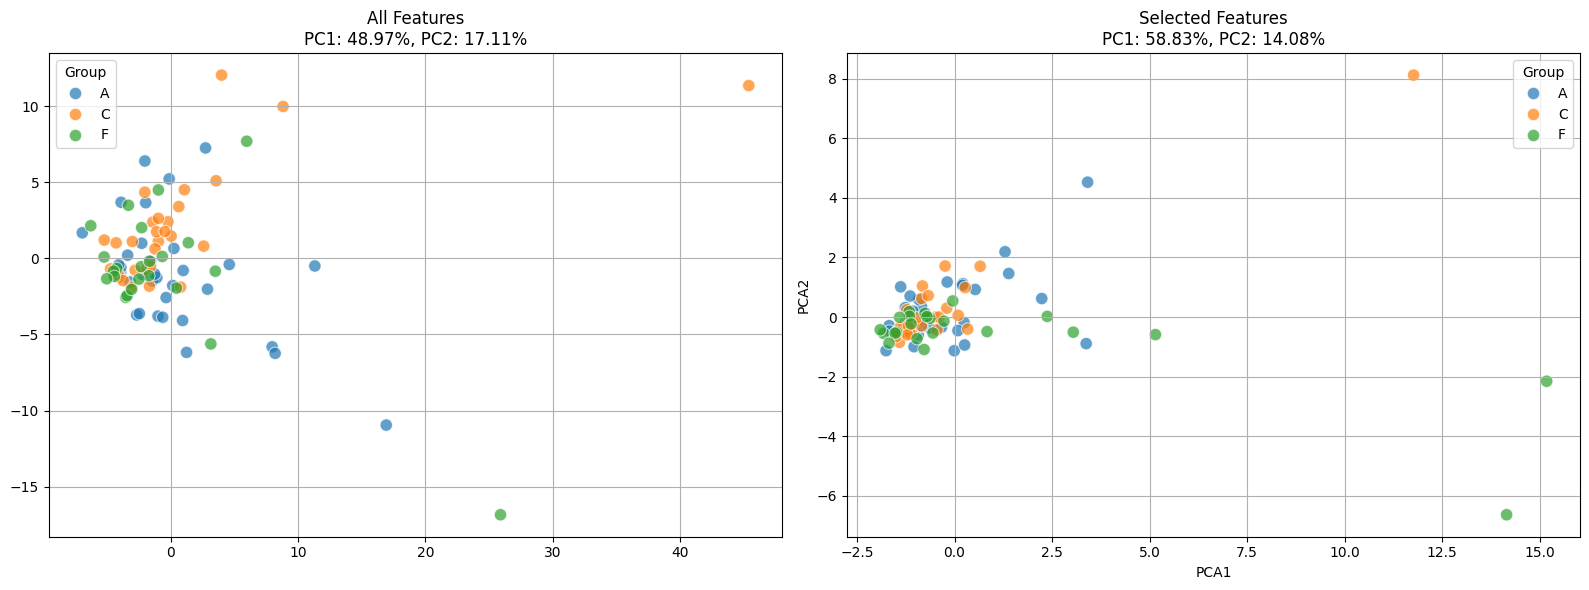

In [7]:
# --------------- PCA on EEG features --------------- #

# BEFORE (all features) 
X_pca_all, var_all = run_pca(X)

# AFTER (feature selection) 
selected = []
for band in sorted(freq_bands.keys()):
    feats = [c for c in X.columns if band in c]
    if feats:
        kept, _ = drop_highly_correlated_features(df, feats, threshold=0.8) # helper function
        selected += kept
X_red = df[selected]

# keep top 20 most label-correlated
# Note: at threshold=0.8, there are only 14 features to begin 
# with, so this part of sorting and filtering doesn't really matter anymore
corrs = sorted(
    [(c, abs(np.corrcoef(X_red[c], y_numeric)[0, 1])) for c in X_red.columns],
    key=lambda x: x[1],
    reverse=True)
top_feats = [c for c, _ in corrs[:20]]
X_pca_sel, var_sel = run_pca(df[top_feats])

# PLOT PCA
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Before dropping highly correlated features
sns.scatterplot(x=X_pca_all[:, 0], y=X_pca_all[:, 1],
                hue=y, ax=axes[0], s=80, alpha=0.7)
axes[0].set_title(f'All Features\nPC1: {var_all[0]:.2%}, PC2: {var_all[1]:.2%}')
plt.xlabel('PCA1') 
plt.ylabel('PCA2')
axes[0].grid(True)

# After dropping highly correlated features
sns.scatterplot(x=X_pca_sel[:, 0], y=X_pca_sel[:, 1],
                hue=y, ax=axes[1], s=80, alpha=0.7)
axes[1].set_title(f'Selected Features\nPC1: {var_sel[0]:.2%}, PC2: {var_sel[1]:.2%}')
plt.xlabel('PCA1') 
plt.ylabel('PCA2')
axes[1].grid(True)
plt.tight_layout()
plt.show()

## Modeling and Evaluation

This section focuses on three modeling techniques:  

**Model A: Logistic Regression (Lasso)**: since this a multi-class classification problem, logistic regression with Lasso regularization will serve as the baseline model. The L1 penalty will act as an embedded feature selection method and help zero out redundant EEG features and prevent overfitting.     

**Model B: SVM**: SVMs are widely used in the analysis of EEG data. Additionally, as confirmed by the PCA analysis, EEG data typically show nonlinear and complex patterns. This, along with the high dimensionality of the feature set (88 participants vs 98 features), nonlinear models such as SVMs would be the most appropriate choice. SVMs work effectively on small sample, high-dimensional datasets, which is the case here. Since the data is not linearly separable, using the RBF (Radial bias function) kernel would aid in finding a decision boundary by projecting the features into an infinite-dimensional space.  


**Model C: Random Forest**: A Random Forest classifier is also a suitable choice because it provides high interpretability. For example, in addition to finding the decision boundary for classification, we might also be interested in knowing exactly which brain regions were the most important in diagnosis. It allows us to identify which specific brain regions (eg: is frontal alpha signal > -9.5?) are most predictive of each pathology. 

### Preprocessing and Hyperparameter Tuning
   
While preprocessing for modeling, I removed redudant columns from feature set X and excluded Age because the Diagnosis groups have similar age distributions and the sample is age-balanced by design. I encoded categorical variables Gender and diagnosis group correctly and normalized the features so they are on the same scale. 

In [8]:
# Re-define X and y for modeling
# Removing the subject_ids and the target variable from X
# Removing Age as well since the sample is controlled for it
X = df.drop(columns=['participant_id', 'Group','Age']) 
y = df['Group'] 

# Encode categorical variables (gender and target group) first
X['Gender'] = LabelEncoder().fit_transform(X['Gender']) 
le_group = LabelEncoder() 
y_encoded = le_group.fit_transform(y) 
class_names = le_group.classes_ 

# Standardize Features 
scaler = StandardScaler() 
X_scaled = scaler.fit_transform(X) 

#### Choosing K for K-fold cross validation
Instead of a traditional train-test split, I chose stratified k-fold cross validation as it facilitates a more reliable performance estimate on a relatively small dataset (n=88).  

In [9]:
 rs = 42 # random state


I avoided setting k = N or k = N-1 as that can result in a high variance model. Choosing a low k value can result in a high bias model, so I instead decided to visualize the bias-variance tradeoff for different values of k to pick the optimal one for cross validation. 

From the plots, the best choice appears to be **k = 10**. The log-loss is the lowest at this k (ignoring k=2, because that would result in a high bias model), offering lower bias. It also gives us the highest possible precision (around 80%), and high accuracy and recall (around 78%). 

[Alternatively, we could set k=9, as that gives us a better recall as we typically emphasize minimizing the false negatives in medicine. But the improvement in recall is minimal (approximately +0.012%) and not worth the loss in accuracy, recall, and log-loss.]

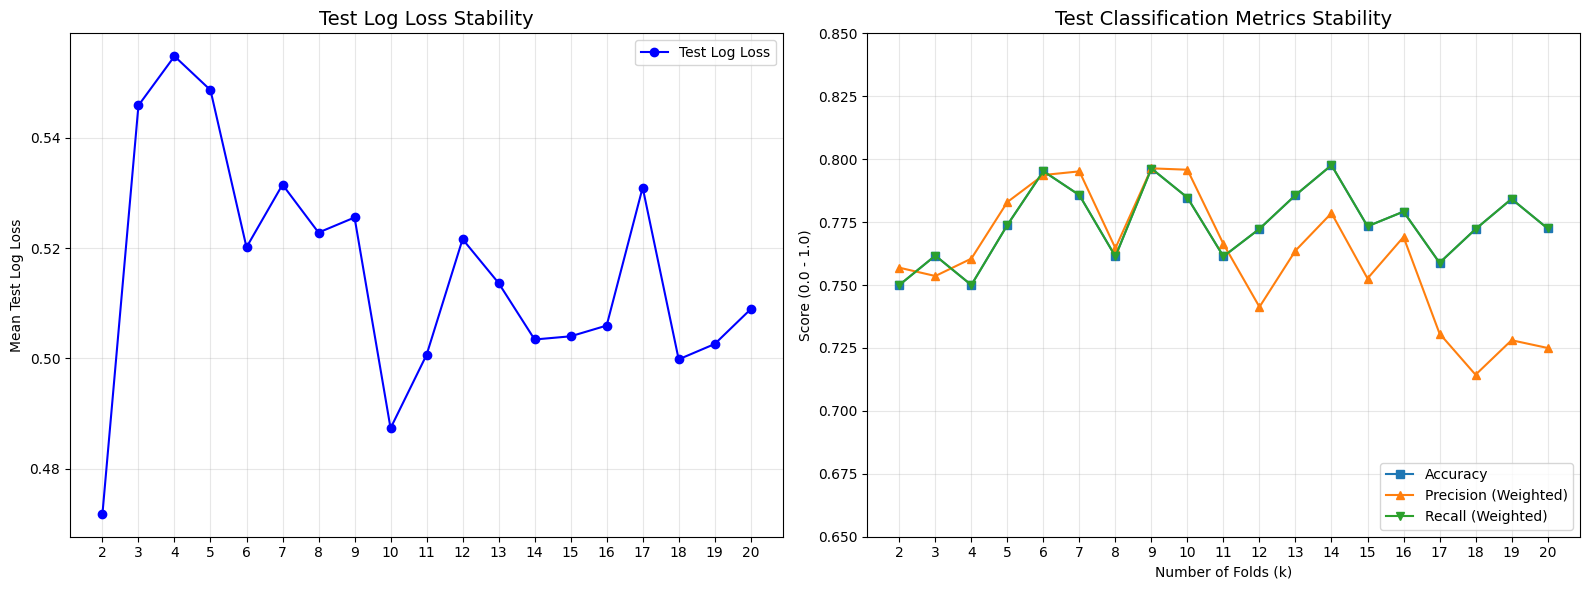

In [10]:
# build a preliminary logistic regression model for choosing k
prelim_model = LogisticRegression(penalty='l1', solver='saga',
                                          max_iter=5000, random_state=rs, n_jobs=-1)
prelim_model.fit(X_scaled, y_encoded)

# Range of k's to check
k_range = range(2, 21) 

# Dictionary to store mean for each metric 
results = { 
    'mean_log_loss': [], # bias
    'mean_accuracy': [], # variance
    'mean_precision': [], # variance
    'mean_recall': [] # variance
} 

precision_weighted = make_scorer(precision_score, average='weighted', zero_division=0) # supress zero division warning

# Iterate through k-folds and compute multiple metrics 
for k in k_range: 
    cv = StratifiedKFold(n_splits=k, shuffle=True, random_state=42) 
    # We use cross_validate to get multiple scores at once 
    scores = cross_validate(prelim_model, X_scaled, y_encoded, cv=cv,
             scoring={'log_loss': 'neg_log_loss',
                        'accuracy': 'accuracy',
                        'precision': precision_weighted,
                        'recall': 'recall_weighted'})

    # Store Log Loss (negated to make it positive) (Bias)
    results['mean_log_loss'].append(-scores['test_log_loss'].mean())

    # Store Classification Metrics (Variance)
    results['mean_accuracy'].append(scores['test_accuracy'].mean())
    results['mean_precision'].append(scores['test_precision'].mean())
    results['mean_recall'].append(scores['test_recall'].mean())

# Plot
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

# Log Loss (Bias)
ax1.plot(k_range, results['mean_log_loss'], marker='o', color='blue', label='Test Log Loss') 
ax1.set_title('Test Log Loss Stability', fontsize=14) 
ax1.set_xticks(k_range)
ax1.set_ylabel('Mean Test Log Loss') 
ax1.grid(True, alpha=0.3) 
ax1.legend() 

# Accuracy, Precision, Recall (Variance)
ax2.plot(k_range, results['mean_accuracy'], marker='s', label='Accuracy') 
ax2.plot(k_range, results['mean_precision'], marker='^', label='Precision (Weighted)') 
ax2.plot(k_range, results['mean_recall'], marker='v', label='Recall (Weighted)') 

ax2.set_title('Test Classification Metrics Stability', fontsize=14) 
ax2.set_xlabel('Number of Folds (k)') 
ax2.set_ylabel('Score (0.0 - 1.0)') 
ax2.set_xticks(k_range) 
ax2.set_ylim(0.65, 0.85) 
ax2.grid(True, alpha=0.3) 
ax2.legend(loc='lower right') 

plt.tight_layout() 
plt.show() 

In [11]:
# Model Implementation with K-fold Cross-Validation 
skf = StratifiedKFold(n_splits=10, shuffle=True, random_state=rs) 

#### Choosing Tree depth

The second hyperparameter that needs tuning is the tree depth for the Random Forest Classifier. Below, I visualized the test accuracy over a range of depth values (1 to 20). The depth with the highest accuracy was 5, followed by 7, after which the accuracy plateaus. Though I am using grid search (GridSearchCV) to choose optimal hyperparameter values for all models, visualizing the depth-accuracy tradeoff gives me a sense of the grid range to specify. A range of [5,6,7,8,9,10] would be appropriate, as it would allow the function to determine whether a combination of tree depth and number of estimators would change where the accuracy peak occurs. This also helps me set the max tree depth for my Surrogate Tree (more on that later.)

Best depth:  5


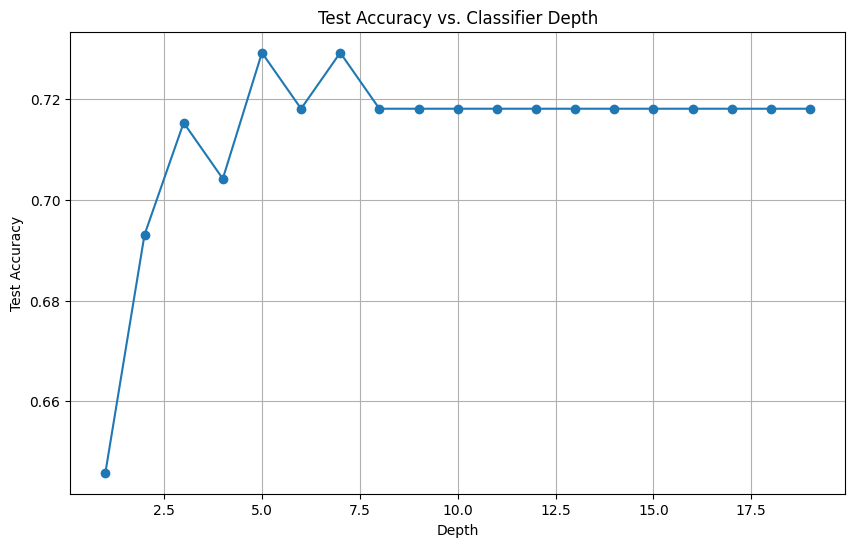

In [24]:
depths = list(range(1, 20)) # the range of depths to check
mean_accuracies = []

for depth in depths: 
    # create a random forests classifier ata given depth
    temp_rf = RandomForestClassifier(random_state=rs, max_depth=depth, n_jobs=-1)
    # evaluate 
    scores = cross_validate(temp_rf, X_scaled, y_encoded, cv=skf, scoring={'accuracy':'accuracy'})
    mean_accuracies.append(scores['test_accuracy'].mean())
    
# Find the best depth
best_depth_idx = np.argmax(mean_accuracies)
best_depth = depths[best_depth_idx]

print("Best depth: ", best_depth)

# Plotting
plt.figure(figsize=(10,6))
plt.plot(depths, mean_accuracies, marker='o')
plt.title('Test Accuracy vs. Classifier Depth')
plt.xlabel('Depth')
plt.ylabel('Test Accuracy')
plt.grid(True)
plt.show()

### Models
Model A implements logistic regression and serves as a baseline, as it is a simple method for classification that models the probability of class membership. Lasso regularization was applied for feature selection to reduce overfitting and retain only the most "informative" features. I chose lasso over other options for feature selection as lasso can zero out redundant features, which is perfectly fine as we have a large set of features.

In [27]:
# --- Model A: Logistic Regression (Lasso) --- 
param_grid_lr = {'C': np.logspace(-3, 2, 10)} 
grid_lr = GridSearchCV(LogisticRegression(penalty='l1', solver='saga',
                                          max_iter=5000, random_state=rs, n_jobs=-1),  
                       param_grid_lr, cv=skf, scoring='f1_weighted') 
grid_lr.fit(X_scaled, y_encoded)

,estimator,LogisticRegre...solver='saga')
,param_grid,{'C': array([1.0000...00000000e+02])}
,scoring,'f1_weighted'
,n_jobs,None
,refit,True
,cv,StratifiedKFo... shuffle=True)
,verbose,0
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,penalty,'l1'


Model B implements an SVM with RBF kernel to determine a decision boundary. It's commonly used in EEG studies.

In [26]:
# --- Model B: SVM (RBF) --- 
param_grid_svm = {'C': [0.1, 1, 10, 100], 'gamma': ['scale', 'auto', 0.01, 0.1]} 
grid_svm = GridSearchCV(SVC(kernel='rbf', probability=True, random_state=rs),  
                        param_grid_svm, cv=skf, scoring='f1_weighted', n_jobs=-1) 
grid_svm.fit(X_scaled, y_encoded)

,estimator,SVC(probabili...ndom_state=42)
,param_grid,"{'C': [0.1, 1, ...], 'gamma': ['scale', 'auto', ...]}"
,scoring,'f1_weighted'
,n_jobs,-1
,refit,True
,cv,StratifiedKFo... shuffle=True)
,verbose,0
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,C,100


Model C implements a Random Forest Classifier. The grid search looks for the optimal hyperparameter combination from the gridspaces of number of estimators and maximum depth ranging from 100-200 and 5-10, respectively.

In [25]:
# --- Model C: Random Forest --- 
param_grid_rf = {'n_estimators': [100, 200], 'max_depth': [5, 6, 7, 8, 9, 10]} 
grid_rf = GridSearchCV(RandomForestClassifier(random_state=rs), param_grid_rf,
                       cv=skf, scoring='f1_weighted', n_jobs=-1) 
grid_rf.fit(X_scaled, y_encoded) 

,estimator,RandomForestC...ndom_state=42)
,param_grid,"{'max_depth': [5, 6, ...], 'n_estimators': [100, 200]}"
,scoring,'f1_weighted'
,n_jobs,-1
,refit,True
,cv,StratifiedKFo... shuffle=True)
,verbose,0
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,n_estimators,200


### Evaluation and Addressing Challenges

The models' classification reports and confusion matrices characterizing test set performance have been visualized below. Interestingly, logistic regression performed the best (78.4% accuracy) while the random forests model performed the worst (73.9%). The SVM, the field's preferred model, performed slightly better at 75% accuracy.

All models performed well at classifying the Healthy Control class. Logistic regression had perfect recall and 94% precision, followed by SVMs at 93% precision and recall. The Random Forest's recall was as good as SVM's but its precision was somewhat lower (84%).

The models showed relatively good performance on differentiating the AD class as well, with the logistic regression and Random Forest having the highest F1-scores (0.77). The SVM wasn't far behind (0.74).

Unfortunately, all models struggled to differentiate the FTD class (which was inarguably the most important), characterized by precision and recall scores not much better than chance (35-61%). 


--- LogReg (Lasso) Results ---
Accuracy: 0.7841
              precision    recall  f1-score   support

           A       0.74      0.81      0.77        36
           C       0.94      1.00      0.97        29
           F       0.61      0.48      0.54        23

    accuracy                           0.78        88
   macro avg       0.76      0.76      0.76        88
weighted avg       0.77      0.78      0.78        88


--- SVM (RBF) Results ---
Accuracy: 0.7500
              precision    recall  f1-score   support

           A       0.76      0.72      0.74        36
           C       0.93      0.93      0.93        29
           F       0.52      0.57      0.54        23

    accuracy                           0.75        88
   macro avg       0.74      0.74      0.74        88
weighted avg       0.76      0.75      0.75        88


--- Random Forest Results ---
Accuracy: 0.7386
              precision    recall  f1-score   support

           A       0.71      0.83      0.7

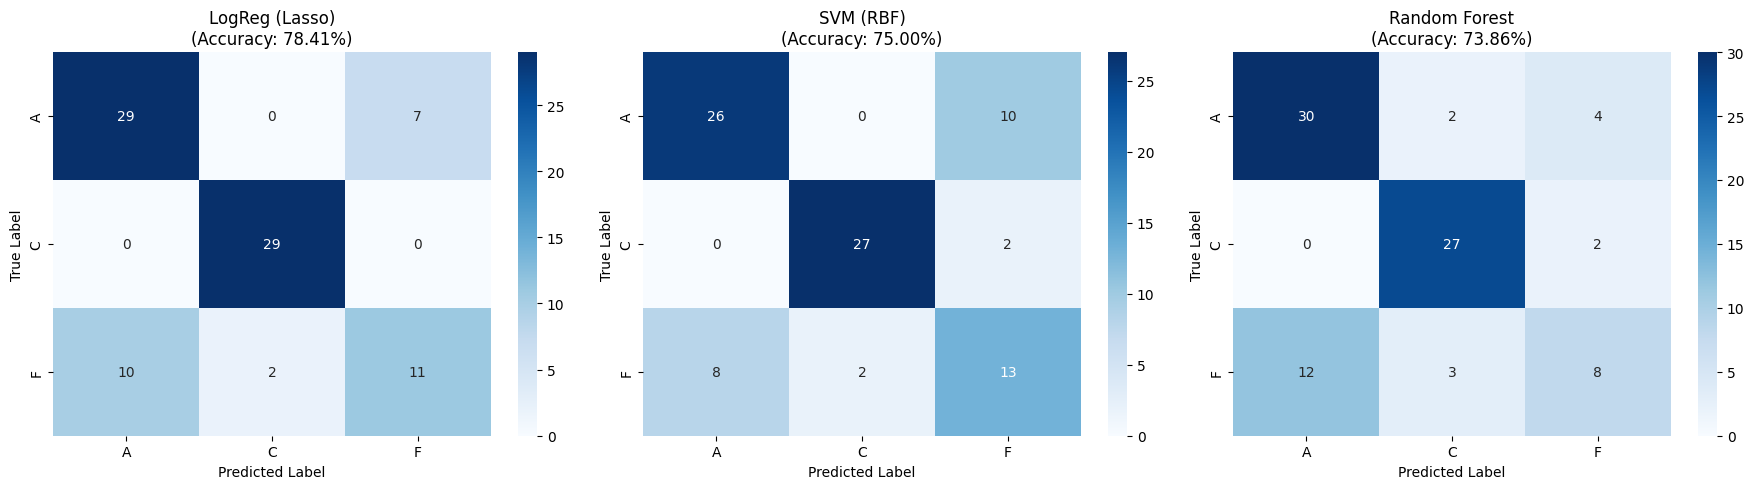

In [28]:
# Evaluation & Final Comparison 
models = [("LogReg (Lasso)", grid_lr.best_estimator_),  
          ("SVM (RBF)", grid_svm.best_estimator_),  
          ("Random Forest", grid_rf.best_estimator_)] 

fig, axes = plt.subplots(1, 3, figsize=(18, 5)) # create layout for confusion matrices

for i, (name, model) in enumerate(models): 
    preds = cross_val_predict(model, X_scaled, y_encoded, cv=skf) 
    print(f"\n--- {name} Results ---") 
    print(f"Accuracy: {accuracy_score(y_encoded, preds):.4f}") 
    print(classification_report(y_encoded, preds, target_names=class_names)) 
    # Generate confusion matrix
    cm = confusion_matrix(y_encoded, preds)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[i],
               xticklabels=class_names, yticklabels=class_names)
    axes[i].set_title(f'{name}\n(Accuracy: {accuracy_score(y_encoded, preds):.2%})')
    axes[i].set_xlabel('Predicted Label')
    axes[i].set_ylabel('True Label')

plt.tight_layout()
plt.show()

A likely reason for the suboptimal performance of non-linear models is that there was no feature selection applied. While Lasso regularization implemented feature selection for logistic regression, the SVM and Random Forest were operating on a much larger feature set and struggled to determine optimal decision boundaries. Modeling on a smaller feature set might improve performance and enhance FTD class differentiation.

To test this theory, I modeled SVM and Random Forest on the subset of EEG features that are not highly correlated with each other. This subset was obtained earlier during the exploratory data analysis. The list 'selected' has 14 EEG band features with <0.8 correlation amongst themselves. The following blocks of code merge the subset with the Gender and MMSE variables, perform SVM and Random Forest modeling on this merged subset containing 16 features, and generate classification reports and confusion matrices for the new models. Logistic regression was not re-run on this subset as Lasso already performed a robust feature selection, and it was meant to serve as a baseline. 

In [29]:
print(selected)
selected = selected + ["Gender", "MMSE"]
X_subset = df[selected] # keep only 14 EEG features + gender and MMSE
y = df['Group'] 

['Fp1_Alpha', 'Fp1_Beta', 'Fp2_Beta', 'F3_Beta', 'C3_Beta', 'T3_Beta', 'Fp1_Delta', 'Fp1_Gamma', 'Fp2_Gamma', 'F3_Gamma', 'C3_Gamma', 'T3_Gamma', 'T4_Gamma', 'Fp1_Theta']


In [30]:
# Encode categorical variables (gender and target group) first
X_subset['Gender'] = LabelEncoder().fit_transform(X_subset['Gender']) 
le_sub_group = LabelEncoder() 
y_sub_encoded = le_sub_group.fit_transform(y) 
class_names = le_group.classes_
subset_feature_names = list(X_subset.columns)

# Standardize Features 
scaler = StandardScaler() 
X_subset_scaled = scaler.fit_transform(X_subset)

C:\Users\nshenoy\AppData\Local\Temp\ipykernel_17644\3923745050.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  X_subset['Gender'] = LabelEncoder().fit_transform(X_subset['Gender'])


In [38]:
X_subset.head()

,Fp1_Alpha,Fp1_Beta,Fp2_Beta,F3_Beta,C3_Beta,T3_Beta,Fp1_Delta,Fp1_Gamma,Fp2_Gamma,F3_Gamma,C3_Gamma,T3_Gamma,T4_Gamma,Fp1_Theta,Gender,MMSE
0,-9.987582,-9.996062,-9.996689,-9.997419,-9.997690,-9.997232,-9.721912,-9.997241,-9.998140,-9.999003,-9.999359,-9.998918,-9.998639,-9.951221,0,16
1,-9.974566,-9.996108,-9.996604,-9.996341,-9.997551,-9.995717,-9.761139,-9.998115,-9.998737,-9.998631,-9.999335,-9.998176,-9.997951,-9.962636,0,22
2,-9.959626,-9.997210,-9.997195,-9.997311,-9.997617,-9.997359,-9.752766,-9.999266,-9.999305,-9.999236,-9.999492,-9.999394,-9.999316,-9.943198,1,14
3,-9.989716,-9.995827,-9.996158,-9.993272,-9.997442,-9.996011,-9.733198,-9.996471,-9.997452,-9.992555,-9.998874,-9.997408,-9.996079,-9.963179,0,20
4,-9.987449,-9.995448,-9.997428,-9.996382,-9.997551,-9.995152,-9.723526,-9.996469,-9.998948,-9.998173,-9.999207,-9.996154,-9.998483,-9.959292,1,22



--- SVM (RBF) Results ---
Accuracy: 0.7727
              precision    recall  f1-score   support

           A       0.70      0.86      0.78        36
           C       0.97      0.97      0.97        29
           F       0.60      0.39      0.47        23

    accuracy                           0.77        88
   macro avg       0.76      0.74      0.74        88
weighted avg       0.76      0.77      0.76        88


--- Random Forest Results ---
Accuracy: 0.8182
              precision    recall  f1-score   support

           A       0.74      0.89      0.81        36
           C       1.00      0.97      0.98        29
           F       0.71      0.52      0.60        23

    accuracy                           0.82        88
   macro avg       0.82      0.79      0.80        88
weighted avg       0.82      0.82      0.81        88



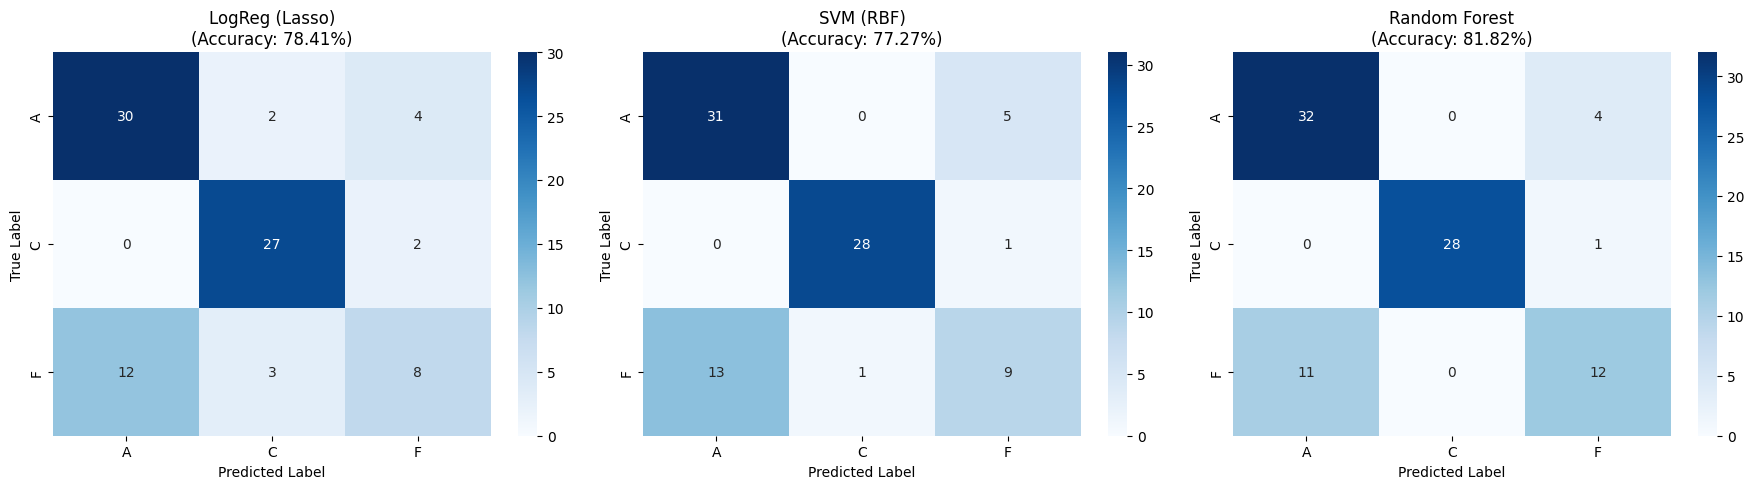

In [32]:
# -------- SVM and Random Forest modeled on selected features  --------- #

# --- Model B2: SVM (RBF) --- 
subset_grid_svm = GridSearchCV(SVC(kernel='rbf', probability=True, random_state=rs),  
                        param_grid_svm, cv=skf, scoring='f1_weighted') 
subset_grid_svm.fit(X_subset_scaled, y_sub_encoded)

# --- Model C2: Random Forest --- 
subset_grid_rf = GridSearchCV(RandomForestClassifier(random_state=rs), param_grid_rf,
                       cv=skf, scoring='f1_weighted', n_jobs=-1) 
subset_grid_rf.fit(X_subset_scaled, y_sub_encoded) 


# Evaluation & Final Comparison 
subset_models = [("SVM (RBF)", subset_grid_svm.best_estimator_),  
          ("Random Forest", subset_grid_rf.best_estimator_)] 

fig, axes = plt.subplots(1, 3, figsize=(18, 5)) # create layout for confusion matrices

# Add logistic regression model back for comparison
cm = confusion_matrix(y_sub_encoded, preds)
preds = cross_val_predict(grid_lr.best_estimator_, 
                          X_scaled, y_encoded, cv=skf) 
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[0],
           xticklabels=class_names, yticklabels=class_names)
axes[0].set_title(f'{"LogReg (Lasso)"}\n(Accuracy: {accuracy_score(y_encoded, preds):.2%})')
axes[0].set_xlabel('Predicted Label')
axes[0].set_ylabel('True Label')

for i, (name, model) in enumerate(subset_models): 
    preds = cross_val_predict(model, X_subset_scaled, y_sub_encoded, cv=skf) 
    print(f"\n--- {name} Results ---") 
    print(f"Accuracy: {accuracy_score(y_sub_encoded, preds):.4f}") 
    print(classification_report(y_sub_encoded, preds, target_names=class_names)) 
    
    # Generate confusion matrix
    cm = confusion_matrix(y_sub_encoded, preds)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[i+1],
               xticklabels=class_names, yticklabels=class_names)
    axes[i+1].set_title(f'{name}\n(Accuracy: {accuracy_score(y_sub_encoded, preds):.2%})')
    axes[i+1].set_xlabel('Predicted Label')
    axes[i+1].set_ylabel('True Label')

plt.tight_layout()
plt.show()

Feature selection improved both models. The SVM's accuracy rose from 75% to 77.3%, almost on par with logistic regression. SVM's AD (F1 score 0.74 vs 0.78) and Healthy Control (F1 score 0.93 vs 0.97) differentiation improved as well. However, its FTD differention remained poor (F1 score 0.47).

The Random Forest, on the other hand, surpassed all previous models, including the logistic regression, and achieved an accuracy of 81.8%. Its accuracy prior to feature selection was 73.9%, resulting in a gain of almost 8% in accuracy. The Random Forest showed remarkable improvements in classifying AD (F1 score 0.77 vs 0.81) and Healthy Control classes, reaching a near-perfect F1 score on the later (0.98). Though its FTD differentiation improved after feature selection (F1 score 0.43 vs 0.60), it is still somewhat low, especially the recall (52%). However, its precision and recall both surpassed that of the logistic regression (precision 0.61 vs 0.71, recall 0.48 vs 0.52). **The 16-feature set Random Forest classifier is undoubtably the best model**, offering the highest accuracy and the lowest false positive and false negative rates. 

Next, the Random Forest allows us to "visualize" the classification and potentially determine the brain regions that can help differentiate each of the three classes. The bar chart below shows the ten most discriminating features of this model (i.e. features with the highest importance scores). Though there is no direct method to visualize a tree to summarize or aggregate the Random Forest's classifications, a surrogate tree is the closest alternative. The surrogate tree is a decision tree modeled on the Random Forest's predictions (rf_behavior). Though it does not reflect the Random Forest's behavior with 100% accuracy, it attempts a close approximation and (from my understanding) is meant to offer interpretability rather than present concrete results.

Both the bar chart and the surrogate tree show that the Random Forest classifier can differentiate the three classes largely based on the MMSE score alone. In the surrogate tree, the classifier uses MMSE to first separate the AD and Control classes, and can fully separate the Control class using this metric. It then separates AD from FTD using MMSE again, at which point the Gini Impurity is already very small. The EEG features offer additional support (importance scores < 0.1), and may help in providing a slightly more nuanced differentiation between AD and FTD. Theta, Gamma, and Beta appear to be the most important frequency bands, and the key brain regions are the prefrontal (Fp1 and Fp2), frontal (F3), and temporal (T3) lobes. This confirms the relevance of the MMSE and the Theta band observed during the exploratory analysis.

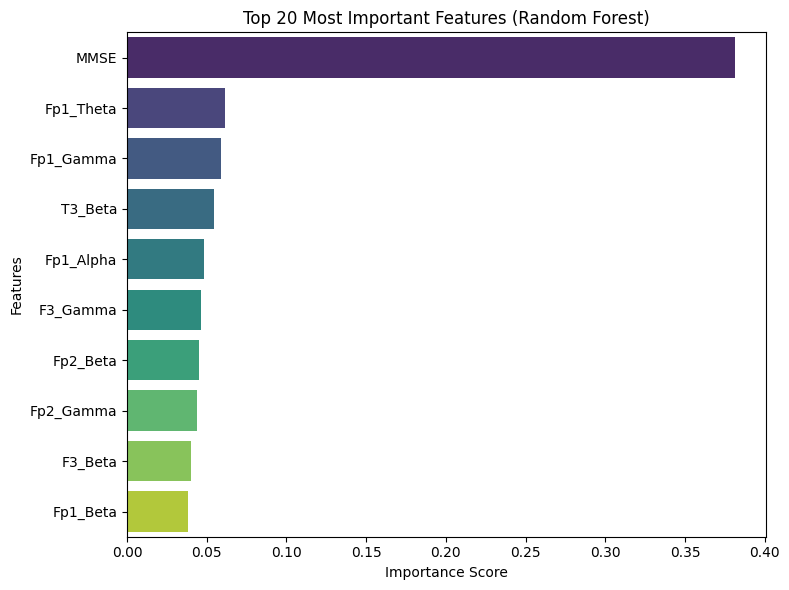

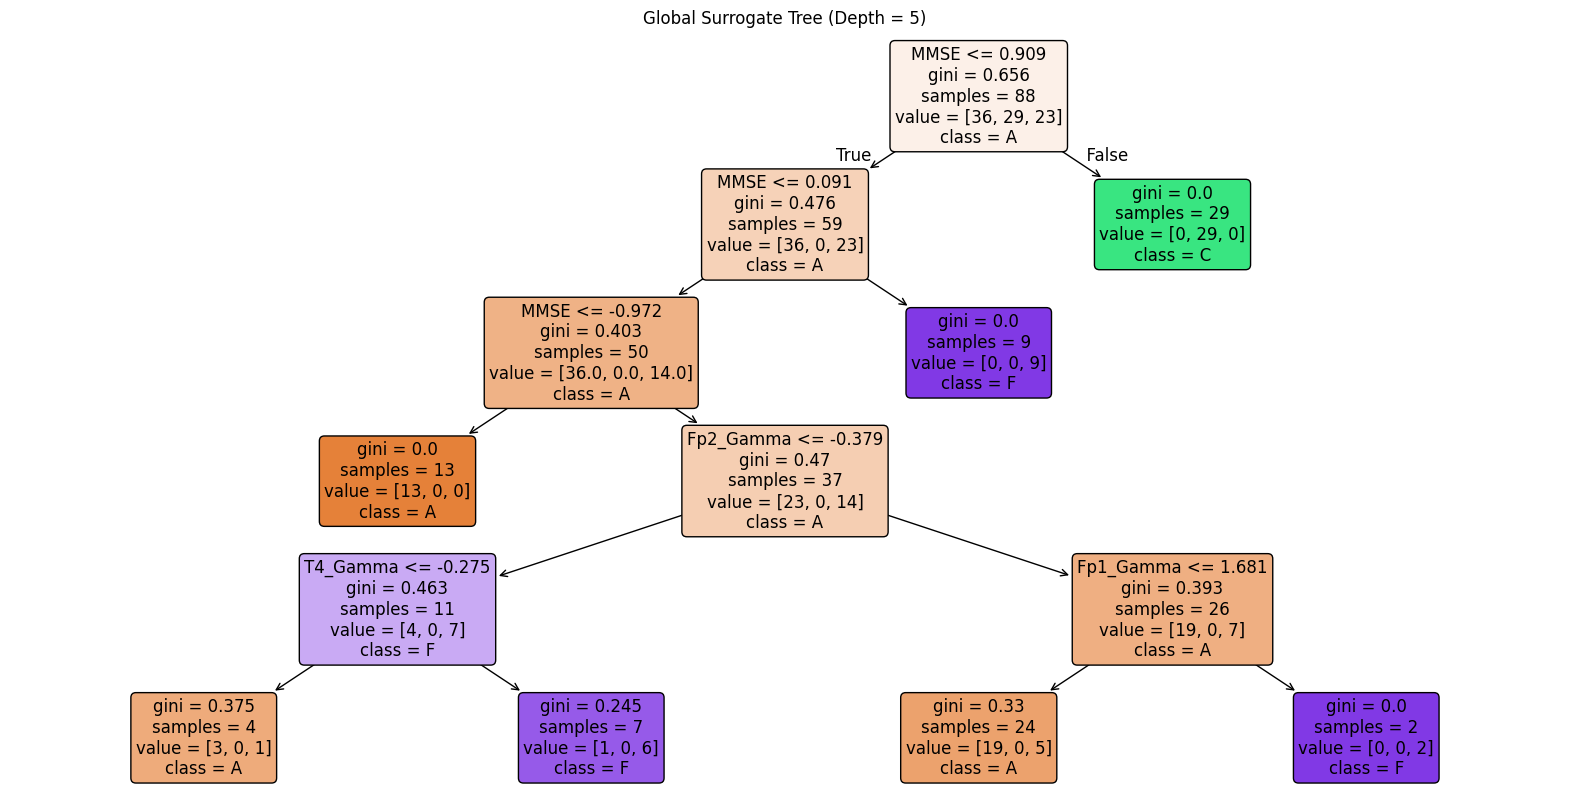

In [37]:
# 1. Visualize Top 10 Features 
importances = subset_grid_rf.best_estimator_.feature_importances_ 

top_indices = np.argsort(importances)[::-1][:10]  # top 10
top_features = [subset_feature_names[i] for i in top_indices]
top_importances = importances[top_indices]

plt.figure(figsize=(8, 6)) 
sns.barplot(x=top_importances, y=top_features, hue=top_features, palette='viridis', legend=False) 
plt.title(f'Top 10 Most Important Features (Random Forest)') 
plt.xlabel('Importance Score') 
plt.ylabel('Features') 
plt.tight_layout() 

# 2. Visualize Surrogate Tree
# Get Model C's predictions
rf_behavior = subset_grid_rf.predict(X_subset_scaled)

# We limit max_depth to 3 for readability in the plot 
surrogate = DecisionTreeClassifier(max_depth=best_depth, random_state=rs)
surrogate.fit(X_subset_scaled, rf_behavior)

plt.figure(figsize=(20, 10))

plot_tree(surrogate,  
          feature_names=subset_feature_names,  
          class_names=list(class_names),  
          filled=True,  
          rounded=True,  
          max_depth=best_depth,  
          fontsize=12)
plt.title("Global Surrogate Tree (Depth = 5)") 
plt.show()

## Conclusions 

AD, FTD and Healthy Controls can be differentiated largely based on the cognitive score. EEG Theta, Gamma and Beta bands from the prefrontal cortex, frontal and temporal lobes may further aid in separating AD from FTD cases. 

The Random Forest model outperformed its counterparts with a peak accuracy of 81.82% because reducing the feature set from 95 down to 14 allowed the model to focus its decision trees on high-impact variables, most notably the MMSE score and prefrontal Theta power, without being distracted by the noise and redundancy of correlated EEG channels. Its inherent robustness to variance and ability to capture non-linear interactions made it ideal for a clinical dataset with a small sample size (n=88).

It may seem counterintuitive that a linear model (i.e. the logistic regression) initially outperformed non-linear ones (SVM and Random forest) on data that is not linearly separable. Clinical metrics like MMSE often have a strong monotonic (and roughly linear) relationship with cognitive decline. If the MMSE score provided most of the predictive power, then the linear model captured that signal perfectly without adding the variance and potential for error that comes with the "wiggly" decision boundaries of the non-linear models.

Interestingly, SVM performed the worst (77.27%) despite its popularity in EEG research, likely because its RBF kernel is highly sensitive to hyperparameter tuning and can struggle to define stable decision boundaries when clinical signatures between AD and FTD heavily overlap. This shows that established industry standards may not always be the best choice for the data we have at hand. 

Lastly, the small size is quite small for a 3-class classification, which may have further impeded the ability of these models to extrapolate the collective contributions of EEG band features. EEG signatures of AD and FTD may also begin to overlap in the later stages of the disease, further hampering discernment. 